# Making counterfactual predictions for colorectal cancer tissue with `Cellina`

In this notebook, we will demonstrate how to use both `Cellina` variants to disentangle spatial from non-spatial variation and make predictions under counterfactual scenarios.

1. Load and pre-process data
2. Train `Cellina` variants (base and GCN)
3. Qualitative analysis (visualize latent spaces)
4. Counterfactual inference
    - Edge perturbation
    - Node perturbation

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [92]:
import numpy as np
import scanpy as sc
import torch
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from scvi.train._callbacks import SaveCheckpoint, EarlyStopping
from scipy.stats import pearsonr

from cellina import Cellina, CellinaGCN, make_neighbor_perturbation, make_perturbed_expression
from cellina._spatial_utils import spatial_neighbors, compute_spatial_features

In [3]:
# Fixing seeds and ensuring deterministic behavior for reproducibility
seed = 0
np.random.seed(seed)  # NumPy
torch.manual_seed(seed)  # PyTorch CPU
torch.cuda.manual_seed(seed)  # PyTorch GPU (single-GPU)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 1. Data preprocessing

### Load adata and preprocess

In [4]:
adata = sc.read(
    f"./data/crc_232.h5ad",
    backup_url=f"https://zenodo.org/records/15574384/files/232.h5ad?download=1"
)
adata.obs_names_make_unique()

For the CRC data, we define a custom celltype label map which groups together major cell types.

In [5]:
label_to_coarse = {
    "epi1": "Epithelial",
    "epi2": "Epithelial",
    "epi3": "Epithelial",
    "epi4": "Epithelial",
    
    "fib1": "Fibroblast",
    "fib2": "Fibroblast",
    
    "EC": "Endothelial",
    "SMC": "Smooth_muscle",
    
    "BC": "B_cell",
    "PC_IgA": "Plasma_cell",
    "PC_IgG": "Plasma_cell",
    "PC_IgM": "Plasma_cell",
    
    "TC": "T_cell",
    
    "mye1": "Myeloid",
    "mye2": "Myeloid",
    
    "mast": "Mast_cell",
}

adata.obs["coarse_type"] = adata.obs['ist'].map(label_to_coarse)

In [6]:
# Set annotation keys
labels_key = 'coarse_type'
domains_key = 'typ'
batch_key = 'sid'

In [7]:
# Filtering and QC
adata = adata[~adata.obs[domains_key].isna()]
adata = adata[~adata.obs[labels_key].isna()]

sc.pp.filter_cells(adata, min_counts=3)
sc.pp.filter_genes(adata, min_counts=3)

/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:174: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


In [8]:
# HVG selection
adata.layers['counts'] = adata.X.copy()
sc.pp.highly_variable_genes(adata, layer='counts', flavor='seurat_v3', n_top_genes=2000, subset=True)

### Data splits

For this demo, we will holdout Fibroblats in the cancer (CRC) region

In [59]:
holdout_ct = 'Myeloid'
is_tumor_region  = adata.obs[domains_key].str.contains("CRC", regex=True)
is_holdout_ct = adata.obs[labels_key] == holdout_ct

# Combine for test set
test_mask = (is_tumor_region) & (is_holdout_ct)
test_idx = np.where(test_mask)[0]

# Get train/val indices
all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

In [60]:
adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [61]:
validation_size = 0.1
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=validation_size,
    random_state=0,
    shuffle=True,
)

In [62]:
print("Train size:", len(train_idx))
print("Validation size:", len(val_idx))
print("Test size:", len(test_idx))

Train size: 96258
Validation size: 10696
Test size: 5035


### Spatial features preprocessing

As we are performing an out-of-distribution inference on CRC Fibroblasts, we want to keep them out when computing adjacency and spatial feature aggregation. We store original adjacency structure for inference.

In [131]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

max_neighbors = 50
adata.obsm['spatial'] = adata.obs[['CenterX_global_px', 'CenterY_global_px']].values
adata.obsp['spatial_connectivities_orig'] = spatial_neighbors(adata, bandwidth=100 / 0.12028, 
                                                              max_neighbours=max_neighbors, 
                                                              standardize=False, 
                                                              inplace=False)

# Recompute with test indices masked out, to avoid data leakage in spatial features for test set
spatial_neighbors(adata, bandwidth=100 / 0.12028, 
                  max_neighbours=max_neighbors, 
                  standardize=False, 
                  test_indices=test_idx)
compute_spatial_features(adata)

adata.X = adata.layers['counts'].copy()  # reset to raw counts for cellina

## 2. Training

In [133]:
model_class = 'gcn'

In [138]:
train_args = {
    "max_epochs": 100,
    "batch_size": 2048,
    "check_val_every_n_epoch": 1,
    "early_stopping": True,
    "enable_checkpointing": True,
    "early_stopping_patience": 5,
    "early_stopping_monitor": "vae_loss_validation",
    "devices": [0],
    "datasplitter_kwargs": {"external_indexing": [train_idx, val_idx, test_idx]},
    "callbacks": [
        SaveCheckpoint(
            monitor='vae_loss_validation',
            dirpath=f"scvi_log/cellina/",
            load_best_on_end=True),
        EarlyStopping(
            monitor="vae_loss_validation",
            patience=5,
            mode="min"),
            ],
}

plan_kwargs = {
    "lr": 1e-3,
    "normalize_losses": True,
}

We define args separately for `Cellina`-base and `Cellina-GAT`.
First we train `Cellina`

In [68]:
cellina_args = {
    "n_latent": 64,
    "use_observed_lib_size": True,
    "condition_on_intrinsic": False,
    "classifier_lambda": 1.0,
    "discriminator_lambda": 1.0,
    "gene_likelihood": "nb",
    'n_layers': 2,
}

In [69]:
Cellina.setup_anndata(adata, 
                      batch_key=batch_key,
                      labels_key=labels_key,
                      domains_key=domains_key,
                      spatial_obsm_key='spatial_x',
                      layer='counts')
cellina_model = Cellina(adata, **cellina_args)

INFO     Generating sequential column names                                                                        
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [70]:
cellina_model.train(**train_args, plan_kwargs=plan_kwargs)

/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:251: UserWarning: Last batch will have a small size of 2 samples. Consider changing settings.batch_size or batch_size in model.train from currently 2048 to avoid errors during model training or change the given external indices accordingly.
  self.n_train, self.n_val = validate_data_split_with_external_indexing(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /data/a330d/projects/cellina/scvi_log/cellina exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value o

Epoch 14/100:  14%|█▍        | 14/100 [00:36<03:46,  2.64s/it, v_num=1, train_loss=28.2]
INFO     File                                                                                                      
         /data/a330d/projects/cellina/scvi_log/cellina/epoch=8-step=768-vae_loss_validation=326.17816162109375/mode
         l.pt already downloaded                                                                                   
Monitored metric vae_loss_validation did not improve in the last 5 records. Best score: 326.178. Signaling Trainer to stop.


And now train `Cellina-GAT` - the `link_prediction_weight` controls the contribution of the custom contrastive loss. For all our experiments we keep unit weights for each training component.

In [140]:
cellina_gat_args = {
    "n_latent": 64,
    "use_observed_lib_size": True,
    "condition_on_intrinsic": False,
    "classifier_lambda": 1.0,
    "discriminator_lambda": 1.0,
    "link_prediction_weight": 1.0,
    "n_layers": 2,
    "convolution_type": 'gat',
    "gene_likelihood": 'nb',
}

train_args["batch_size"] = 512
train_args["callbacks"] = [
    SaveCheckpoint(
    monitor='vae_loss_validation',
    dirpath=f"scvi_log/cellina-gat/",
    load_best_on_end=True),
    EarlyStopping(
    monitor="vae_loss_validation",
    patience=5,
    mode="min"),
]

In [141]:
CellinaGCN.setup_anndata(adata, 
                         batch_key=batch_key, 
                         labels_key=labels_key, 
                         domains_key=domains_key,
                         layer='counts',
                         spatial_connectivities_key='spatial_connectivities')
cellina_gat = CellinaGCN(adata, **cellina_gat_args)

INFO     cellina: The CellinaGCN model has been initialized with adversarial domain forgetting with edge prediction


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [143]:
cellina_gat.train(**train_args, plan_kwargs=plan_kwargs)

/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:251: UserWarning: Last batch will have a small size of 2 samples. Consider changing settings.batch_size or batch_size in model.train from currently 512 to avoid errors during model training or change the given external indices accordingly.
  self.n_train, self.n_val = validate_data_split_with_external_indexing(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


Epoch 21/100:  20%|██        | 20/100 [32:48<2:13:19, 99.99s/it, v_num=1, train_loss=196] 


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [144]:
model = cellina_model if model_class == 'base' else cellina_gat

## 3. Qualitative Analysis

We can now visualize the latent spaces of each `Cellina` model - the basal representation $z$ should cluster w.r.t cell type labels, while the spatial representation $s$ should encode regions (REF, TVA, CRC)

In [38]:
checkpoint_name = os.listdir("scvi_log/cellina/")[0]
model = Cellina.load(
    f"scvi_log/cellina/{checkpoint_name}",
    adata=adata,
)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File scvi_log/cellina/epoch=27-step=8694-vae_loss_validation=320.0311584472656/model.pt already downloaded
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [87]:
adata.obsm['cellina_basal'] = model.get_latent_representation(latent_key='z', batch_size=2048)
adata.obsm['cellina_spatial'] = model.get_latent_representation(latent_key='s', batch_size=2048)

In [88]:
sc.pp.neighbors(adata, use_rep='cellina_basal')
sc.tl.umap(adata)

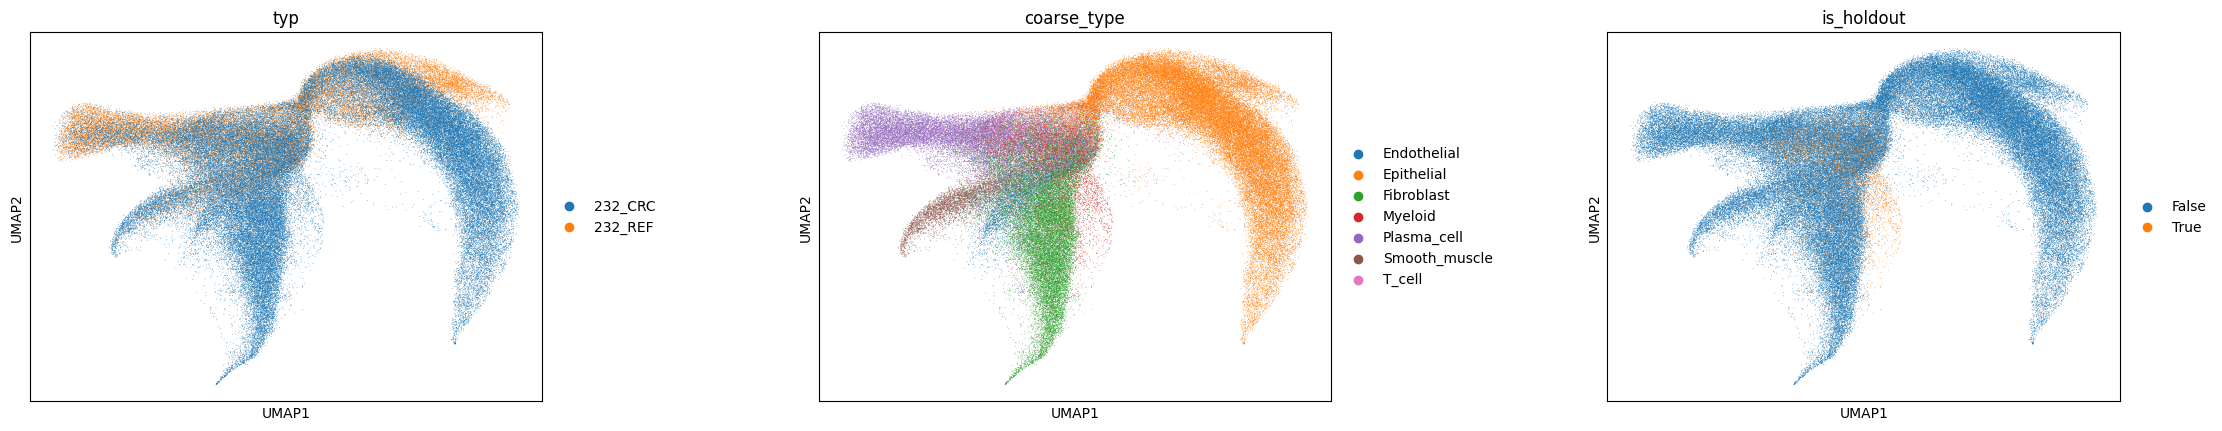

In [89]:
sc.pl.umap(adata, color=[domains_key, labels_key, 'is_holdout'], wspace=0.4)

In [90]:
sc.pp.neighbors(adata, use_rep='cellina_spatial')
sc.tl.umap(adata)

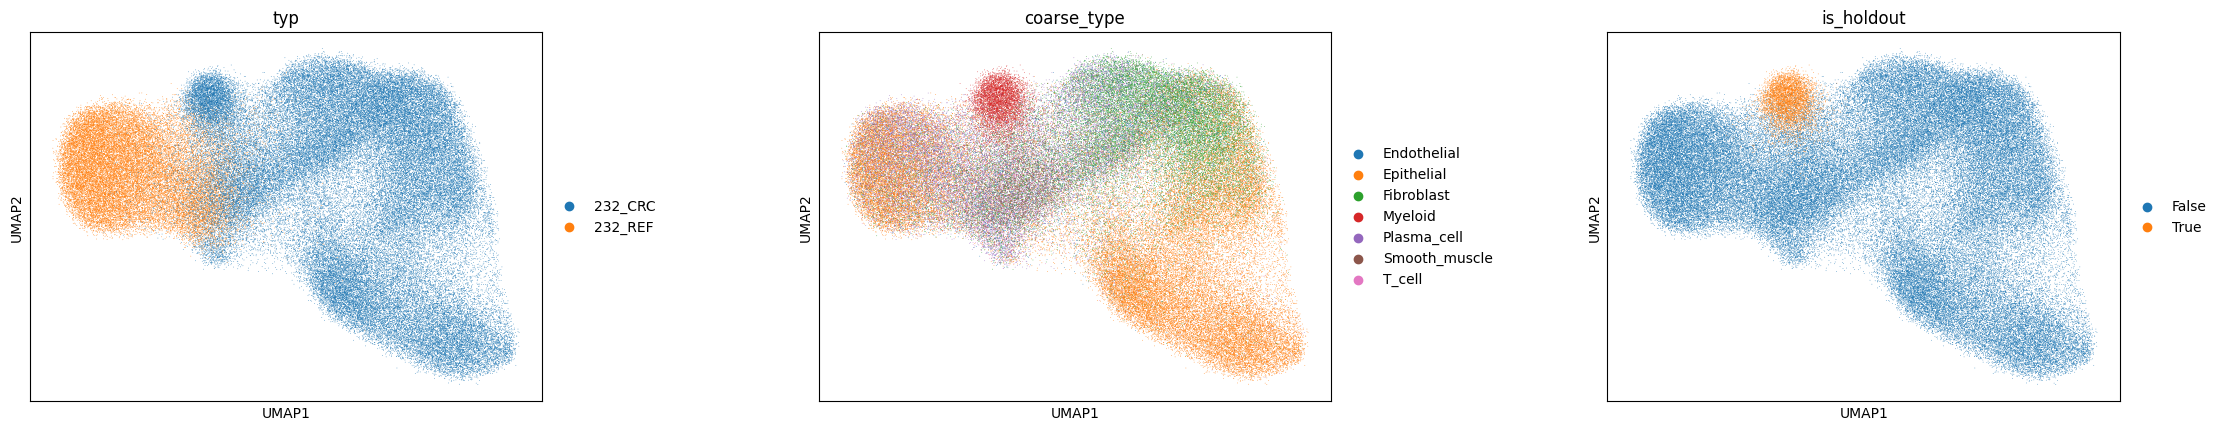

In [91]:
sc.pl.umap(adata, color=[domains_key, labels_key, 'is_holdout'], wspace=0.4)

## 4. Counterfactuals

We now perform two specific out-of-distribution inference tasks defined on tissue graphs: **edge** and **node** perturbation. *Edge perturbation* performs an in-silico intervention on the graph structure itself - in our case this corresponds to taking control Fibroblasts and replacing their observed neighboring cells with those of unseen cancer Fibroblasts

### 4.1 Edge perturbation

The core idea of edge perturbation is modifying a cell's neighborhood.

This could be:
1. Replacing a neighboring cell with another cell
2. Removing a neighboring cell
3. Adding a neighboring cell

In our case, we will do a specific type of replacement: We will replace the neighbors of healthy Fibroblasts with the neighbors of cancer Fibroblasts. This will demonstrate whether `Cellina` learns the effect of neighboring cells on a focal cell in an unseen setting.

First, we get indices of *control* and *target* cells. *Control* cells are Fibroblasts that we have seen during training (in the healthy region),
and *target* cells are Fibroblasts in the cancer region that were held-out during training.
We call these *target* cells because we want to apply in-silico perturbations to *control* cells to look like *target* cells.

In [146]:
is_control_region = adata.obs[domains_key].str.contains('REF')
mask_control = is_control_region & is_holdout_ct
idx_control = np.where(mask_control.values)[0]            

mask_target = is_tumor_region & is_holdout_ct
idx_target = np.where(mask_target.values)[0]

Now, we want to get the indices of cells from which to sample new neighboring cells for healthy Fibroblasts i.e. the set of observed neighbors of cancer Fibroblasts.

In [147]:
# "neighbour_indices" are indices of the neighbors of idx_target cells
conn = adata.obsp["spatial_connectivities_orig"]
sub_conn = conn[idx_target]                # rows for target cells
neighbor_indices = sub_conn.nonzero()[1]   # all neighbors at once
neighbor_indices = np.unique(neighbor_indices)
# remove neighbors having same ct as holdout_ct
neighbor_indices = neighbor_indices[~is_holdout_ct.values[neighbor_indices]]

In [ ]:
args_gex = {
    "indices": idx_control,
    "batch_size": 1024,
    "seed": 0,
    "neighbour_indices": neighbor_indices,
}

# For Cellina-GAT, this tells the sampler how many neighbors to assign to each focal cell
if model_class != 'base':
    args_gex["n_neighbors_per_seed"] = 50
else:
    args_gex["precomputed"] = False

counterfactual_counts = model.get_counterfactual_expression(**args_gex)

In [118]:
def _normalize_counts(x, eps=1e-8, scale=1e4):
    return x / (x.sum(axis=1, keepdims=True) + eps) * scale

def safe_log2_fold_change(a, b, eps=1e-6):
    """
    Compute log2((a + eps) / (b + eps)) elementwise.
    Use this instead of log2(a - b). eps should be set relative to normalized scale.
    """
    a = np.asarray(a)
    b = np.asarray(b)
    return np.log2((a + eps) / (b + eps))

def get_lfc(control, target, counterfactual, normalize_counts=True, n_deg=200):
    if normalize_counts:
        control = _normalize_counts(control)
        target = _normalize_counts(target)
        counterfactual = _normalize_counts(counterfactual)

    mean_control = np.nanmean(control, axis=0)
    mean_target = np.nanmean(target, axis=0)
    mean_cf = np.nanmean(counterfactual, axis=0)

    # compute log2 fold changes
    gt_vec = safe_log2_fold_change(mean_target, mean_control)
    cf_vec = safe_log2_fold_change(mean_cf, mean_control)

    deg_scores = np.abs(gt_vec)
    top_features = np.argsort(-deg_scores)[:n_deg]

    return gt_vec, cf_vec, top_features

Finally, we compare ground-truth log-fold change of healthy vs. cancer Myeloids to that of healthy vs. counterfactual Myeloids

In [119]:
control = np.array(adata.layers['counts'][mask_control.values, :].todense())
target = np.array(adata.layers['counts'][mask_target.values, :].todense())
counterfactual = counterfactual_counts

true_lfc, pred_lfc, deg = get_lfc(control=control, target=target, counterfactual=counterfactual, n_deg=20)

In [120]:
pearson, _ = pearsonr(true_lfc[deg], pred_lfc[deg])

As we see, `Cellina` transforms healthy Myeloid cells to cancer Myeloids by swapping neighbors.

In [121]:
def plot_lfc(true_lfc, pred_lfc, deg, gene_names, holdout_ct, pearson):
    # Sort by true LFC for visualization
    fig, ax = plt.subplots(figsize=(5, 4))

    non_deg = np.setdiff1d(np.arange(len(true_lfc)), deg)

    ax.scatter(
        true_lfc[non_deg],
        pred_lfc[non_deg],
        alpha=0.3,
        s=10,
        color="lightgray"
    )

    ax.scatter(
        true_lfc[deg],
        pred_lfc[deg],
        s=40,
        color="red"
    )

    for i in deg:
        ax.annotate(
            gene_names[i],
            (true_lfc[i], pred_lfc[i]),
            fontsize=8
        )

    lims = [
        min(true_lfc.min(), pred_lfc.min()),
        max(true_lfc.max(), pred_lfc.max())
    ]

    ax.plot(lims, lims, "k--")

    ax.set_xlabel("Observed logFC")
    ax.set_ylabel("Predicted logFC")
    ax.set_title(f"Observed vs predicted logFC in {holdout_ct} cells (pearson={pearson:.2f})")
    plt.show()

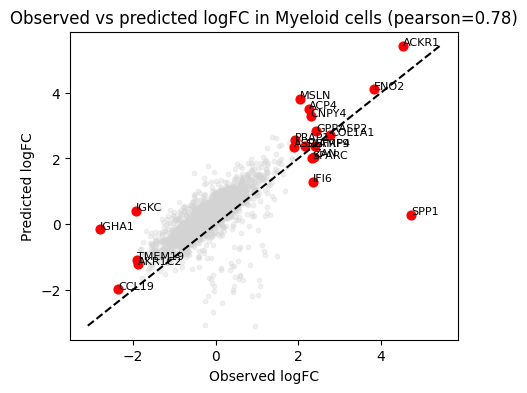

In [122]:
gene_names = np.array(adata.var_names)

plot_lfc(true_lfc, pred_lfc, deg, gene_names, holdout_ct, pearson)

### 4.2 Node perturbation

A complementary perturbation to a tissue graph can be in the form of, not modifying the graph structure, rather the features of existing neighbors. As an example, in tissue biology this corresponds to effects of CRISPR perturbations on neighboring cells. We call this type of intervention **node perturbation**.

Once again, while in theory this could be an arbitrary modification of gene features of neighboring cells, we simulate it by shifting *top-n* neighboring genes by the observed log-fold change in healthy vs. cancer populations. We do this per-celltype, and importantly, the shift applied to holdout cells is the global average log-fold change as the model must not observe it.

In [123]:
n_pert_genes = 200
control_domain = '232_REF'
target_domain = '232_CRC'

Here we define helper functions to compute logFC (global and cell type-specific)

In [124]:
import pandas as pd
import scipy.sparse as sp
import decoupler as dc

def get_perturbation_logfc(adata, control_domain, holdout_domain, labels_key, domains_key):
    # Cell-type-specific
    pdata_ct = dc.pp.pseudobulk(
        adata=adata, sample_col=domains_key, groups_col=labels_key, mode='sum', layer='counts'
    )
    sc.pp.normalize_total(pdata_ct, target_sum=1e4)
    sc.pp.log1p(pdata_ct)

    cell_types_with_both = [
        ct for ct in pdata_ct.obs[labels_key].unique()
        if ((pdata_ct.obs[domains_key] == control_domain) & (pdata_ct.obs[labels_key] == ct)).any()
        and ((pdata_ct.obs[domains_key] == holdout_domain) & (pdata_ct.obs[labels_key] == ct)).any()
    ]

    _ct_rows = []
    for _ct in cell_types_with_both:
        _crc_ct = pdata_ct[(pdata_ct.obs[domains_key] == holdout_domain) & (pdata_ct.obs[labels_key] == _ct)].X
        _ref_ct = pdata_ct[(pdata_ct.obs[domains_key] == control_domain) & (pdata_ct.obs[labels_key] == _ct)].X
        _crc_m  = np.asarray(_crc_ct.mean(axis=0)).flatten() if sp.issparse(_crc_ct) else _crc_ct.mean(axis=0).flatten()
        _ref_m  = np.asarray(_ref_ct.mean(axis=0)).flatten() if sp.issparse(_ref_ct) else _ref_ct.mean(axis=0).flatten()
        _ct_rows.append(pd.Series(_crc_m - _ref_m, index=pdata_ct.var_names, name=_ct))
    domain_logfc_df = pd.concat(_ct_rows, axis=1).T

    return domain_logfc_df


def get_global_perturbation_logfc(adata, control_domain, holdout_domain, labels_key, domains_key, holdout_ct):
    adata_sub = adata[adata.obs[labels_key]!=holdout_ct]
    pdata_global = dc.pp.pseudobulk(
        adata=adata_sub, sample_col=domains_key, groups_col=None, mode='sum', layer='counts'
    )
    sc.pp.normalize_total(pdata_global, target_sum=1e4)
    sc.pp.log1p(pdata_global)

    _holdout_X    = pdata_global[pdata_global.obs[domains_key] == holdout_domain].X
    _control_X    = pdata_global[pdata_global.obs[domains_key] == control_domain].X
    _holdout_mean = np.asarray(_holdout_X.mean(axis=0)).flatten() if sp.issparse(_holdout_X) else _holdout_X.mean(axis=0).flatten()
    _control_mean = np.asarray(_control_X.mean(axis=0)).flatten() if sp.issparse(_control_X) else _control_X.mean(axis=0).flatten()
    
    return pd.Series(_holdout_mean - _control_mean, index=pdata_global.var_names)

In [125]:
# Cell-type-specific perturbation
domain_logfc_df = get_perturbation_logfc(adata, control_domain, target_domain, labels_key, domains_key)
global_logfc_series = get_global_perturbation_logfc(adata, control_domain, target_domain, labels_key, domains_key, holdout_ct)
domain_logfc_df.loc[holdout_ct, global_logfc_series.index] = global_logfc_series # NOTE: set the holdout celltype's perturbation to the global perturbation - ct

logfc_series_dict = {}
for ct in domain_logfc_df.index:
    s = domain_logfc_df.loc[ct]
    top_g = s.abs().nlargest(n_pert_genes).index.tolist()
    logfc_series_dict[ct] = s[top_g]

Node perturbation differs between `Cellina` and `Cellina-GCN` - the former operates on aggregated neighbor features, and therefore we apply a shift in log-space i.e. additive shift. For `Cellina-GCN`, the shift is applied to each cell in the neighborhood individually.

In [126]:
if model_class == 'base':
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    make_neighbor_perturbation(
            adata, 
            perturbations=logfc_series_dict, 
            groupby=labels_key,
            obsm_key_out='spatial_x_cf', 
            base=np.e,
            renormalize=True,
            add_shift=True,
    )
    pert_expr = model.get_perturbed_expression(
        adata=adata, indices=idx_control, spatial_obsm_key='spatial_x_cf',
        batch_size=2048, library_size=1e4,
    )

In [ ]:
if model_class != 'base':
    cf_layer_key = f'counts_cf_{target_domain.lower()}'
    make_perturbed_expression(
        adata,
        perturbations=logfc_series_dict,
        groupby=labels_key,
        layer_key=cf_layer_key,
        base=np.e,
        add_shift=False,
        renormalize=True)
    pert_expr = model.get_perturbed_expression(
        adata=adata, indices=idx_control,
        cf_layer=cf_layer_key,
        batch_size=512, library_size=1e4,
    )

In [128]:
control = np.array(adata.layers['counts'][mask_control.values, :].todense())
target = np.array(adata.layers['counts'][mask_target.values, :].todense())
counterfactual = pert_expr

true_lfc, pred_lfc, deg = get_lfc(control=control, target=target, counterfactual=counterfactual, n_deg=20)

In [129]:
pearson, _ = pearsonr(true_lfc[deg], pred_lfc[deg])

Once again, we see that `Cellina` predicts the effect of neighboring gene modifications on the holdout Myeloid population.

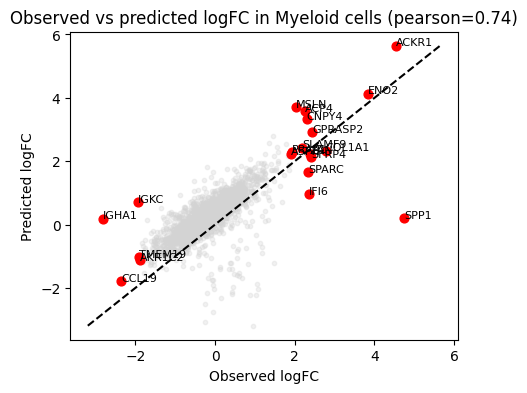

In [130]:
plot_lfc(true_lfc, pred_lfc, deg, gene_names, holdout_ct, pearson)